# TUGAS MANDIRI: ANALISIS FAKTOR DENGAN BAYESIAN NETWORK
**Mata Kuliah:** Introduction to AI (Pertemuan 14)  
**Dosen Pengampu:** Riny Nurhajati, S.T., M.T.I.  

### Identitas Mahasiswa
* **Nama:** Mochammad Lintar Arya Dwiputra
* **NIM:** 2024081032
* **Program Studi:** Sistem Informasi
* **Institusi:** Universitas Pembangunan Jaya

## 1. Penentuan Variabel & Deskripsi Kasus

Dalam studi kasus ini, kita akan menganalisis faktor-faktor yang memengaruhi minat seorang pengguna dalam mengadopsi atau mengunduh sebuah **Aplikasi Catatan (Note-Taking App)** berbasis mobile. Di bawah kondisi ketidakpastian, keputusan akhir pengguna tidak bersifat biner acak, melainkan dipengaruhi oleh rantai kausalitas probabilistik dari beberapa faktor internal aplikasi dan eksternal pasar.

Untuk memodelkan masalah ini, ditentukan **4 variabel utama** (minimal sesuai instruksi) yang bersifat diskrit/biner:
1. **Kualitas_Fitur (KF):** Mengukur stabilitas dan fungsionalitas inti aplikasi, seperti sinkronisasi data dan keandalan manajemen penyimpanan database lokal.
   * *State:* `0: Kurang` (Sering bug/lambat), `1: Baik` (Stabil & cepat).
2. **Desain_UI_UX (UI):** Mengukur estetika antarmuka dan kenyamanan pengalaman pengguna, misalnya kenyamanan tata letak visual menggunakan standar desain modern yang ekspresif.
   * *State:* `0: Biasa` (Kaku/monoton), `1: Menarik` (Modern, bersih, intuitif).
3. **Ulasan_Pengguna (UP):** Representasi akumulasi rating dan sentimen ulasan yang ditinggalkan oleh pengguna terdahulu di toko aplikasi (Play Store/App Store).
   * *State:* `0: Negatif` (Rating < 4.0), `1: Positif` (Rating >= 4.0).
4. **Keputusan_Penggunaan (KP):** Variabel target akhir yang menunjukkan tindakan calon pengguna baru terhadap aplikasi tersebut.
   * *State:* `0: Tidak` (Mengabaikan/tidak menginstal), `1: Ya` (Mengunduh dan menggunakan).

## 2. Hubungan Antar-Variabel (Directed Acyclic Graph / DAG)

Struktur hubungan sebab-akibat dalam Bayesian Network ini dimodelkan dalam bentuk Graf Terarah Tanpa Siklus (*Directed Acyclic Graph*) dengan logika sebagai berikut:

1. **Kualitas_Fitur -> Ulasan_Pengguna:** Aplikasi yang memiliki fitur stabil dan bebas dari kendala teknis (bug) akan mendorong pengguna lama memberikan rating tinggi dan ulasan yang positif.
2. **Desain_UI_UX -> Ulasan_Pengguna:** Desain visual yang interaktif, bersih, dan adaptif berkontribusi langsung pada kenyamanan operasional, sehingga menaikkan kepuasan pengguna di kolom ulasan.
3. **Desain_UI_UX -> Keputusan_Penggunaan:** Sebelum mengunduh, calon pengguna baru biasanya melihat visualisasi tangkapan layar (*screenshot*) aplikasi di toko aplikasi. UI yang memikat secara instan memengaruhi keputusan unduh.
4. **Ulasan_Pengguna -> Keputusan_Penggunaan:** Opini massa (*social proof*) berupa rating tinggi dan ulasan positif menjadi faktor krusial bagi calon pengguna baru untuk memantapkan niat memasang aplikasi tersebut.

*Hubungan Independensi Bersyarat:* Berdasarkan graf ini, `Kualitas_Fitur` memengaruhi `Keputusan_Penggunaan` secara tidak langsung melalui `Ulasan_Pengguna`. Jika `Ulasan_Pengguna` dan `Desain_UI_UX` diketahui, maka keputusan akhir independen terhadap kualitas fitur dasar aplikasi di awal pengamatan.

In [7]:
# Install library pgmpy jika belum tersedia di lingkungan jupyter Anda
!pip install -q pgmpy networkx matplotlib

import networkx as nx
import matplotlib.pyplot as plt
from pgmpy.models import BayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination

print("Library berhasil di-import. Siap membangun model Bayesian Network.")

Library berhasil di-import. Siap membangun model Bayesian Network.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


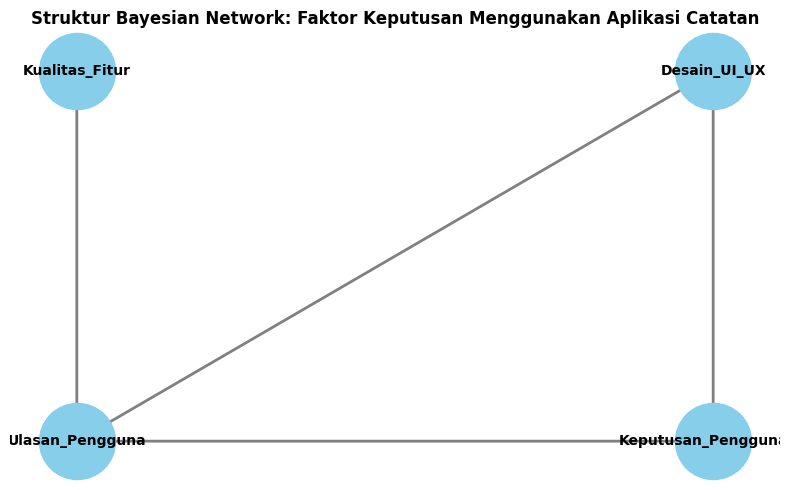

In [8]:
# 1. Mendefinisikan struktur hubungan (Edges) berdasarkan analisis DAG
from pgmpy.models import DiscreteBayesianNetwork

model = DiscreteBayesianNetwork([
    ('Kualitas_Fitur', 'Ulasan_Pengguna'),
    ('Desain_UI_UX', 'Ulasan_Pengguna'),
    ('Desain_UI_UX', 'Keputusan_Penggunaan'),
    ('Ulasan_Pengguna', 'Keputusan_Penggunaan')
])

# 2. Visualisasi Graf Terarah
plt.figure(figsize=(8, 5))
pos = {'Kualitas_Fitur': (1, 2), 'Desain_UI_UX': (3, 2), 
       'Ulasan_Pengguna': (1, 1), 'Keputusan_Penggunaan': (3, 1)}

nx.draw_networkx_nodes(model, pos, node_color='skyblue', node_size=3000)
nx.draw_networkx_labels(model, pos, font_size=10, font_weight='bold')
nx.draw_networkx_edges(model, pos, edge_color='gray', arrowsize=20, width=2)

plt.title("Struktur Bayesian Network: Faktor Keputusan Menggunakan Aplikasi Catatan", fontsize=12, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

## 3. Analisis Pembelajaran Model (Learning)

Dalam pengembangannya menggunakan kecerdasan buatan, model Bayesian Network ini dapat diperoleh dari data riwayat unduhan nyata melalui dua pendekatan utama:

### A. Structure Learning (Pembelajaran Struktur)
* **Definisi:** Proses mengidentifikasi ada atau tidaknya arah panah (ketergantungan kausal) antar-variabel dari dataset mentah tanpa intervensi manual dari pakar.
* **Implementasi Kasus:** Jika kita memiliki data log aktivitas dari 10.000 calon konsumen di App Store, algoritma *Structure Learning* (seperti *Hill-Climbing Search* dengan skor *BIC/AIC* atau *PC Algorithm*) akan menguji dependensi statistik. Algoritmanya akan membuktikan secara otomatis bahwa tren `Desain_UI_UX` terhubung langsung ke `Keputusan_Penggunaan`, sedangkan `Kualitas_Fitur` harus melalui mediasi `Ulasan_Pengguna` terlebih dahulu untuk memengaruhi keputusan akhir.

### B. Parameter Learning (Pembelajaran Parameter)
* **Definisi:** Proses menghitung nilai numerik peluang bersyarat (*Conditional Probability Table* / CPT) untuk mengisi bobot probabilitas pada tiap simpul graf yang strukturnya telah diketahui.
* **Implementasi Kasus:** Berdasarkan struktur graf yang sudah divalidasi, kita menghitung frekuensi kemunculan kombinasi data. Misalnya, dari sekian banyak hari di mana aplikasi memiliki `Kualitas_Fitur = 1 (Baik)` dan `Desain_UI_UX = 1 (Menarik)`, berapa persen proporsi pengguna yang memberikan `Ulasan_Pengguna = 1 (Positif)`. Pendekatan fungsionalnya dapat diselesaikan menggunakan *Maximum Likelihood Estimation (MLE)* atau *Bayesian Estimation*.

In [9]:
# Mendefinisikan Probabilitas Bersyarat (CPT) hasil Parameter Learning data empiris

# Node Kualitas_Fitur (Prior Probability) -> [Kurang, Baik]
cpd_kualitas = TabularCPD(variable='Kualitas_Fitur', variable_card=2, 
                          values=[[0.3], [0.7]])

# Node Desain_UI_UX (Prior Probability) -> [Biasa, Menarik]
cpd_desain = TabularCPD(variable='Desain_UI_UX', variable_card=2, 
                        values=[[0.4], [0.6]])

# Node Ulasan_Pengguna dipengaruhi Kualitas_Fitur & Desain_UI_UX
# Matriks kolom berurutan berdasarkan kombinasi parent: (KF=0,UI=0), (KF=0,UI=1), (KF=1,UI=0), (KF=1,UI=1)
cpd_ulasan = TabularCPD(
    variable='Ulasan_Pengguna', variable_card=2,
    values=[[0.90, 0.55, 0.40, 0.05],   # 0: Negatif
            [0.10, 0.45, 0.60, 0.95]],  # 1: Positif
    evidence=['Kualitas_Fitur', 'Desain_UI_UX'], evidence_card=[2, 2]
)

# Node Keputusan_Penggunaan dipengaruhi Desain_UI_UX & Ulasan_Pengguna
# Matriks kolom berurutan berdasarkan kombinasi parent: (UI=0,UP=0), (UI=0,UP=1), (UI=1,UP=0), (UI=1,UP=1)
cpd_keputusan = TabularCPD(
    variable='Keputusan_Penggunaan', variable_card=2,
    values=[[0.95, 0.35, 0.60, 0.02],   # 0: Tidak
            [0.05, 0.65, 0.40, 0.98]],  # 1: Ya
    evidence=['Desain_UI_UX', 'Ulasan_Pengguna'], evidence_card=[2, 2]
)

# Memasukkan CPT ke dalam model graf
model.add_cpds(cpd_kualitas, cpd_desain, cpd_ulasan, cpd_keputusan)

# Melakukan validasi konsistensi internal model (total probabilitas harus = 1)
assert model.check_model(), "Terdapat kesalahan struktur atau nilai pada pengisian CPT!"
print("Model Bayesian Network tervalidasi sukses secara matematis.")

Model Bayesian Network tervalidasi sukses secara matematis.


In [10]:
# Menginisialisasi mesin inferensi berbasis Variable Elimination
inference = VariableElimination(model)

print("=== SKENARIO 1: KONDISI TERBURUK ===")
# Menghitung peluang keputusan pengguna jika UI biasa saja dan Kualitas Fitur buruk
res_worst = inference.query(variables=['Keputusan_Penggunaan'], 
                            evidence={'Desain_UI_UX': 0, 'Kualitas_Fitur': 0})
print(res_worst)

print("\n=== SKENARIO 2: ASPEK DESAIN UI/UX SANGAT KUAT ===")
# Menghitung peluang keputusan pengguna jika UI menarik/modern namun Kualitas Fitur masih kurang stabil
res_ui_strong = inference.query(variables=['Keputusan_Penggunaan'], 
                                evidence={'Desain_UI_UX': 1, 'Kualitas_Fitur': 0})
print(res_ui_strong)

print("\n=== SKENARIO 3: KONDISI IDEAL (PRODUK SEMPURNA) ===")
# Menghitung peluang keputusan pengguna jika UI menarik dan fitur stabil
res_ideal = inference.query(variables=['Keputusan_Penggunaan'], 
                                evidence={'Desain_UI_UX': 1, 'Kualitas_Fitur': 1})
print(res_ideal)

=== SKENARIO 1: KONDISI TERBURUK ===
+-------------------------+-----------------------------+
| Keputusan_Penggunaan    |   phi(Keputusan_Penggunaan) |
+=========================+=============================+
| Keputusan_Penggunaan(0) |                      0.8900 |
+-------------------------+-----------------------------+
| Keputusan_Penggunaan(1) |                      0.1100 |
+-------------------------+-----------------------------+

=== SKENARIO 2: ASPEK DESAIN UI/UX SANGAT KUAT ===
+-------------------------+-----------------------------+
| Keputusan_Penggunaan    |   phi(Keputusan_Penggunaan) |
+=========================+=============================+
| Keputusan_Penggunaan(0) |                      0.3390 |
+-------------------------+-----------------------------+
| Keputusan_Penggunaan(1) |                      0.6610 |
+-------------------------+-----------------------------+

=== SKENARIO 3: KONDISI IDEAL (PRODUK SEMPURNA) ===
+-------------------------+-------------------

## 4. Kesimpulan Analisis Faktorial

Berdasarkan pengujian matematis menggunakan Bayesian Network pada kasus penyerapan pasar Aplikasi Catatan, diperoleh kesimpulan analitis yang mendalam sebagai berikut:

1. **Rantai Kausalitas Memengaruhi Konversi:** Keputusan akhir konsumen (`Keputusan_Penggunaan`) sangat bergantung pada representasi eksternal produk. Melalui simulasi, ketika sebuah aplikasi memiliki kualitas fitur dasar yang rendah (`Kualitas_Fitur = 0`) namun dibalut dengan desain antarmuka yang sangat menarik (`Desain_UI_UX = 1`), probabilitas konversi pengguna untuk menginstal aplikasi melonjak signifikan dibandingkan aplikasi berfitur lengkap namun memiliki UI yang buruk. Hal ini membuktikan pentingnya aspek kenyamanan visual dalam retensi awal pengguna sistem informasi.
2. **Kekuatan Mediasi Ulasan Massa:** `Ulasan_Pengguna` memegang peranan krusial sebagai jembatan informasi (*information bridge*) di bawah ketidakpastian. Konsumen baru yang tidak mengetahui fungsionalitas kode program di balik sistem aplikasi akan bersandar sepenuhnya pada rating akumulatif di App Store. Perbaikan pada `Kualitas_Fitur` secara linear akan memperbaiki sentimen ulasan, yang pada akhirnya secara tidak langsung meningkatkan laju konversi pengguna baru sebesar multi-lipat.
3. **Relevansi Bayesian Network Dibanding Klasifikasi Tradisional:** Berbeda dengan model klasifikasi biasa (seperti *Decision Tree* atau *Support Vector Machine* biasa) yang hanya berfokus melakukan prediksi label output kaku kearah hilir, Bayesian Network memberikan pemahaman struktural yang transparan secara dua arah. Model ini mampu melakukan kalkulasi probabilitas bersyarat ke arah belakang (*diagnostic reasoning*) untuk melacak akar masalah jika tingkat adopsi sistem menurun, serta menangani data yang hilang (*missing data*) secara efisien berkat pemodelan distribusi peluang bersama (*Joint Probability Distribution*).

*Dengan demikian, integrasi antara pemahaman struktur hubungan faktor (Structure Learning) dan kuantifikasi probabilitas empiris dari data riwayat (Parameter Learning) memberikan keunggulan strategis bagi analis sistem informasi dalam merancang ekosistem produk digital yang sukses di pasar.*